In [1]:
# VoiceBank-DEMAND Dataset - Detailed EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load Dataset
#df = pd.read_csv("/kaggle/input/voicebank-demand-dataset/vb-demand.csv")
df = pd.read_csv("/kaggle/input/voicebank-demand-audio-metadata-for-speech/vb-demand.csv")


# Basic Info
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
display(df.head())

Shape: (12396, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12396 entries, 0 to 12395
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   File          12396 non-null  object 
 1   Set           12396 non-null  object 
 2   Duration      12396 non-null  float64
 3   SamplingRate  12396 non-null  int64  
 4   MaxAmplitude  12396 non-null  float64
 5   MinAmplitude  12396 non-null  float64
 6   SNR           12396 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 678.0+ KB
None

Missing Values:
 File            0
Set             0
Duration        0
SamplingRate    0
MaxAmplitude    0
MinAmplitude    0
SNR             0
dtype: int64


,File,Set,Duration,SamplingRate,MaxAmplitude,MinAmplitude,SNR
0,p226_001.wav,train,2.280000,16000,0.498596,0.0,12.245363
1,p226_002.wav,train,3.900000,16000,0.509064,0.0,8.738602
2,p226_003.wav,train,7.774312,16000,0.491028,0.0,4.108770
3,p226_004.wav,train,5.190000,16000,0.493622,0.0,-0.990553
4,p226_005.wav,train,7.421000,16000,0.499878,0.0,14.149238


In [3]:
# Summary Statistics
display(df.describe())

# Add speaker column
df['Speaker'] = df['File'].apply(lambda x: x.split('_')[0])
print("\nUnique speakers:", df['Speaker'].nunique())

,Duration,SamplingRate,MaxAmplitude,MinAmplitude,SNR
count,12396.000000,12396.000000,12396.000000,12396.0,12396.000000
mean,2.894535,18127.137786,0.493814,0.0,6.280990
std,1.079755,7971.751411,0.011760,0.0,5.662331
min,1.092375,16000.000000,0.226227,0.0,-4.953051
25%,2.215719,16000.000000,0.491478,0.0,1.822070
50%,2.659969,16000.000000,0.496033,0.0,6.775123
75%,3.317359,16000.000000,0.499207,0.0,11.722986
max,15.112063,48000.000000,0.538055,0.0,22.293806



Unique speakers: 30


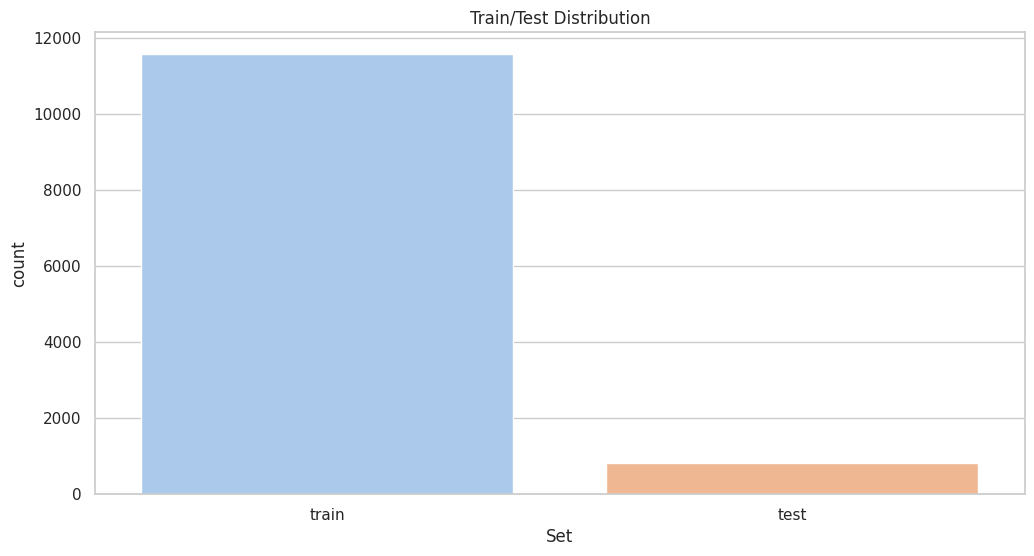

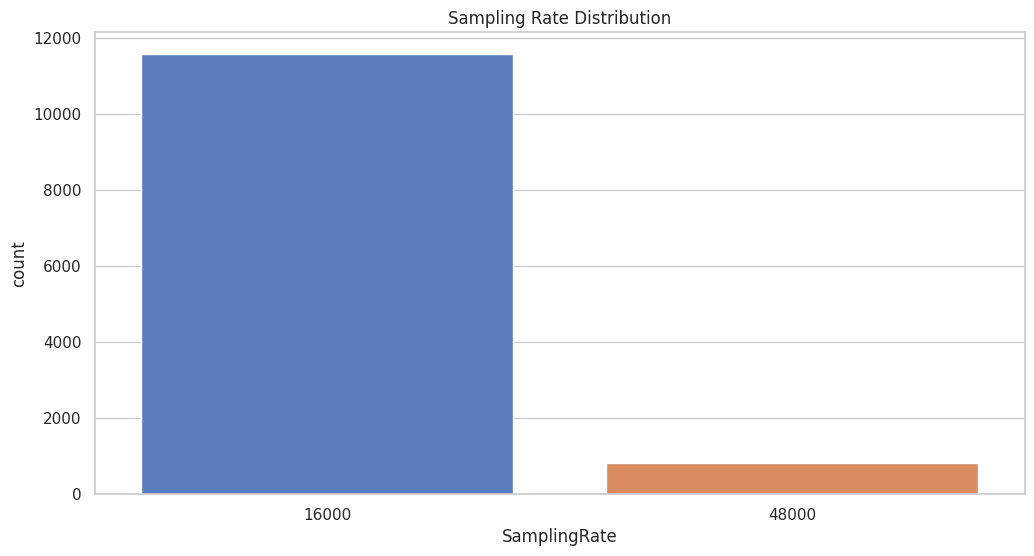

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


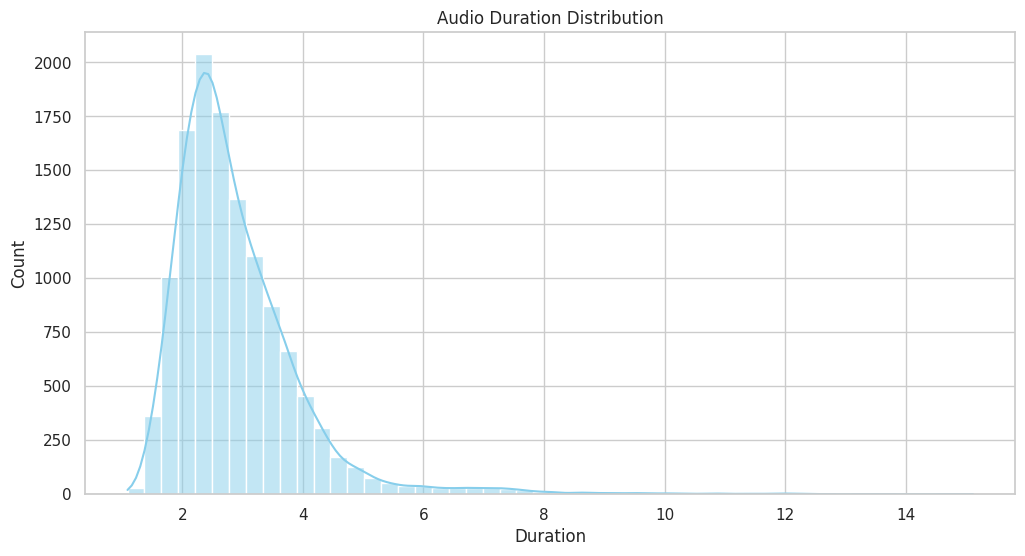

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


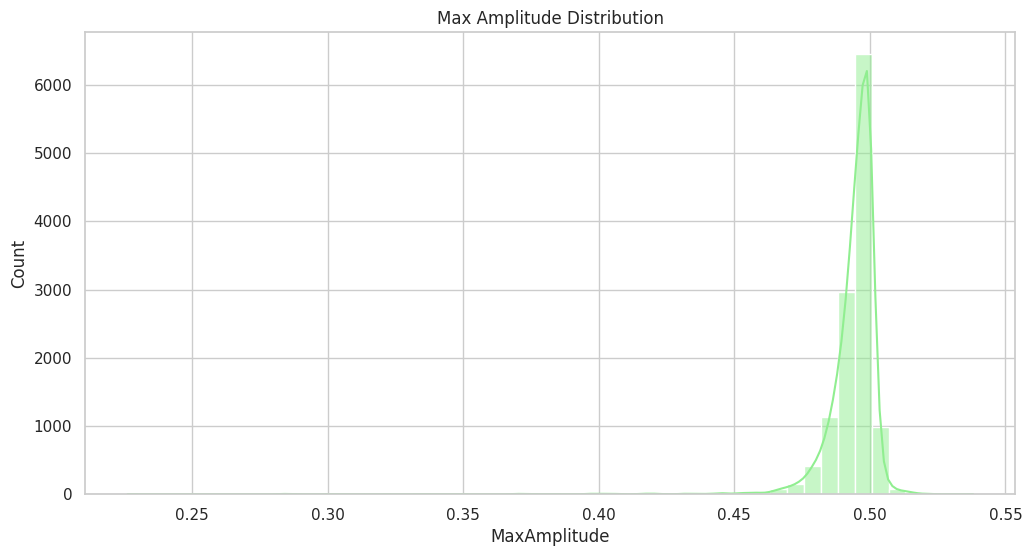

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


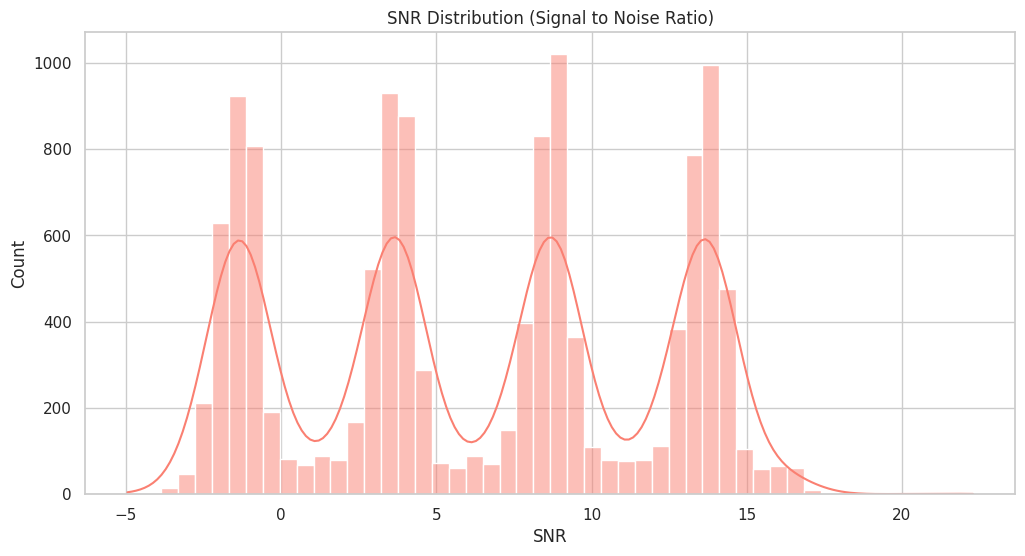

In [4]:
# Train/Test Distribution
sns.countplot(x='Set', data=df, palette='pastel')
plt.title("Train/Test Distribution")
plt.show()

# Sampling Rate Distribution
sns.countplot(x='SamplingRate', data=df, palette='muted')
plt.title("Sampling Rate Distribution")
plt.show()

# Duration Distribution
sns.histplot(df['Duration'], kde=True, bins=50, color='skyblue')
plt.title("Audio Duration Distribution")
plt.show()

# Max Amplitude Distribution
sns.histplot(df['MaxAmplitude'], kde=True, bins=50, color='lightgreen')
plt.title("Max Amplitude Distribution")
plt.show()

# SNR Distribution
sns.histplot(df['SNR'], kde=True, bins=50, color='salmon')
plt.title("SNR Distribution (Signal to Noise Ratio)")
plt.show()


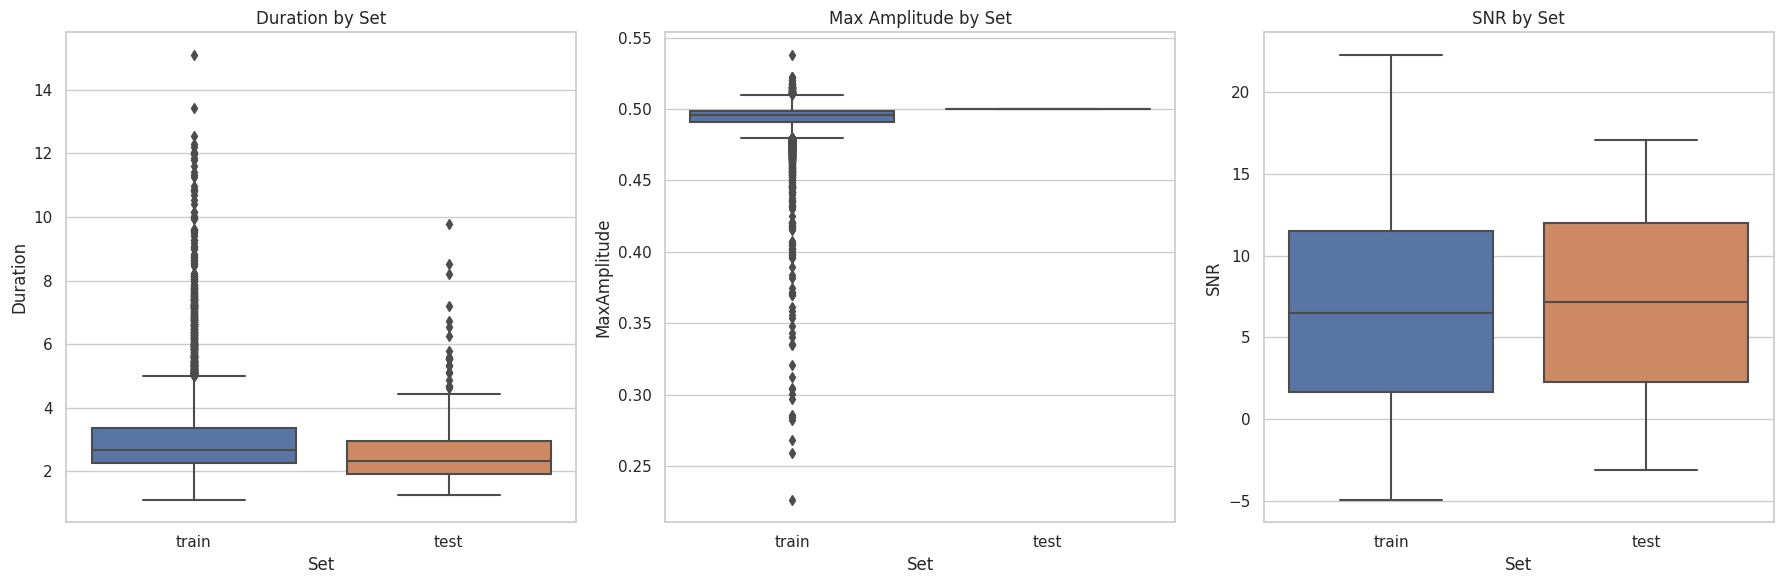

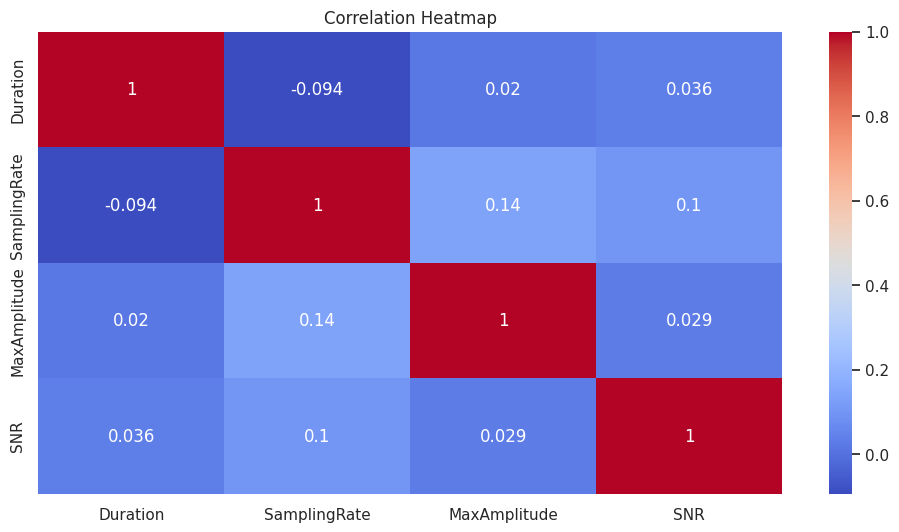

In [5]:

# Boxplots by Set
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=df, y="Duration", x="Set", ax=axes[0])
axes[0].set_title("Duration by Set")
sns.boxplot(data=df, y="MaxAmplitude", x="Set", ax=axes[1])
axes[1].set_title("Max Amplitude by Set")
sns.boxplot(data=df, y="SNR", x="Set", ax=axes[2])
axes[2].set_title("SNR by Set")
plt.tight_layout()
plt.show()

# Correlation Matrix
corr = df[['Duration', 'SamplingRate', 'MaxAmplitude', 'SNR']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



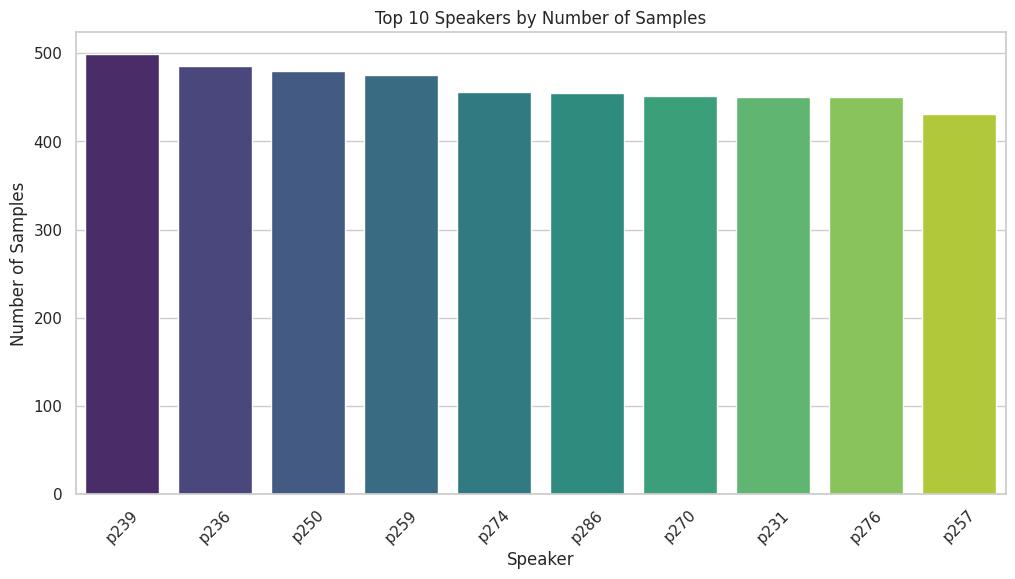

In [6]:
# Top 10 Speakers
top_speakers = df['Speaker'].value_counts().head(10)
sns.barplot(x=top_speakers.index, y=top_speakers.values, palette='viridis')
plt.title("Top 10 Speakers by Number of Samples")
plt.xlabel("Speaker")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

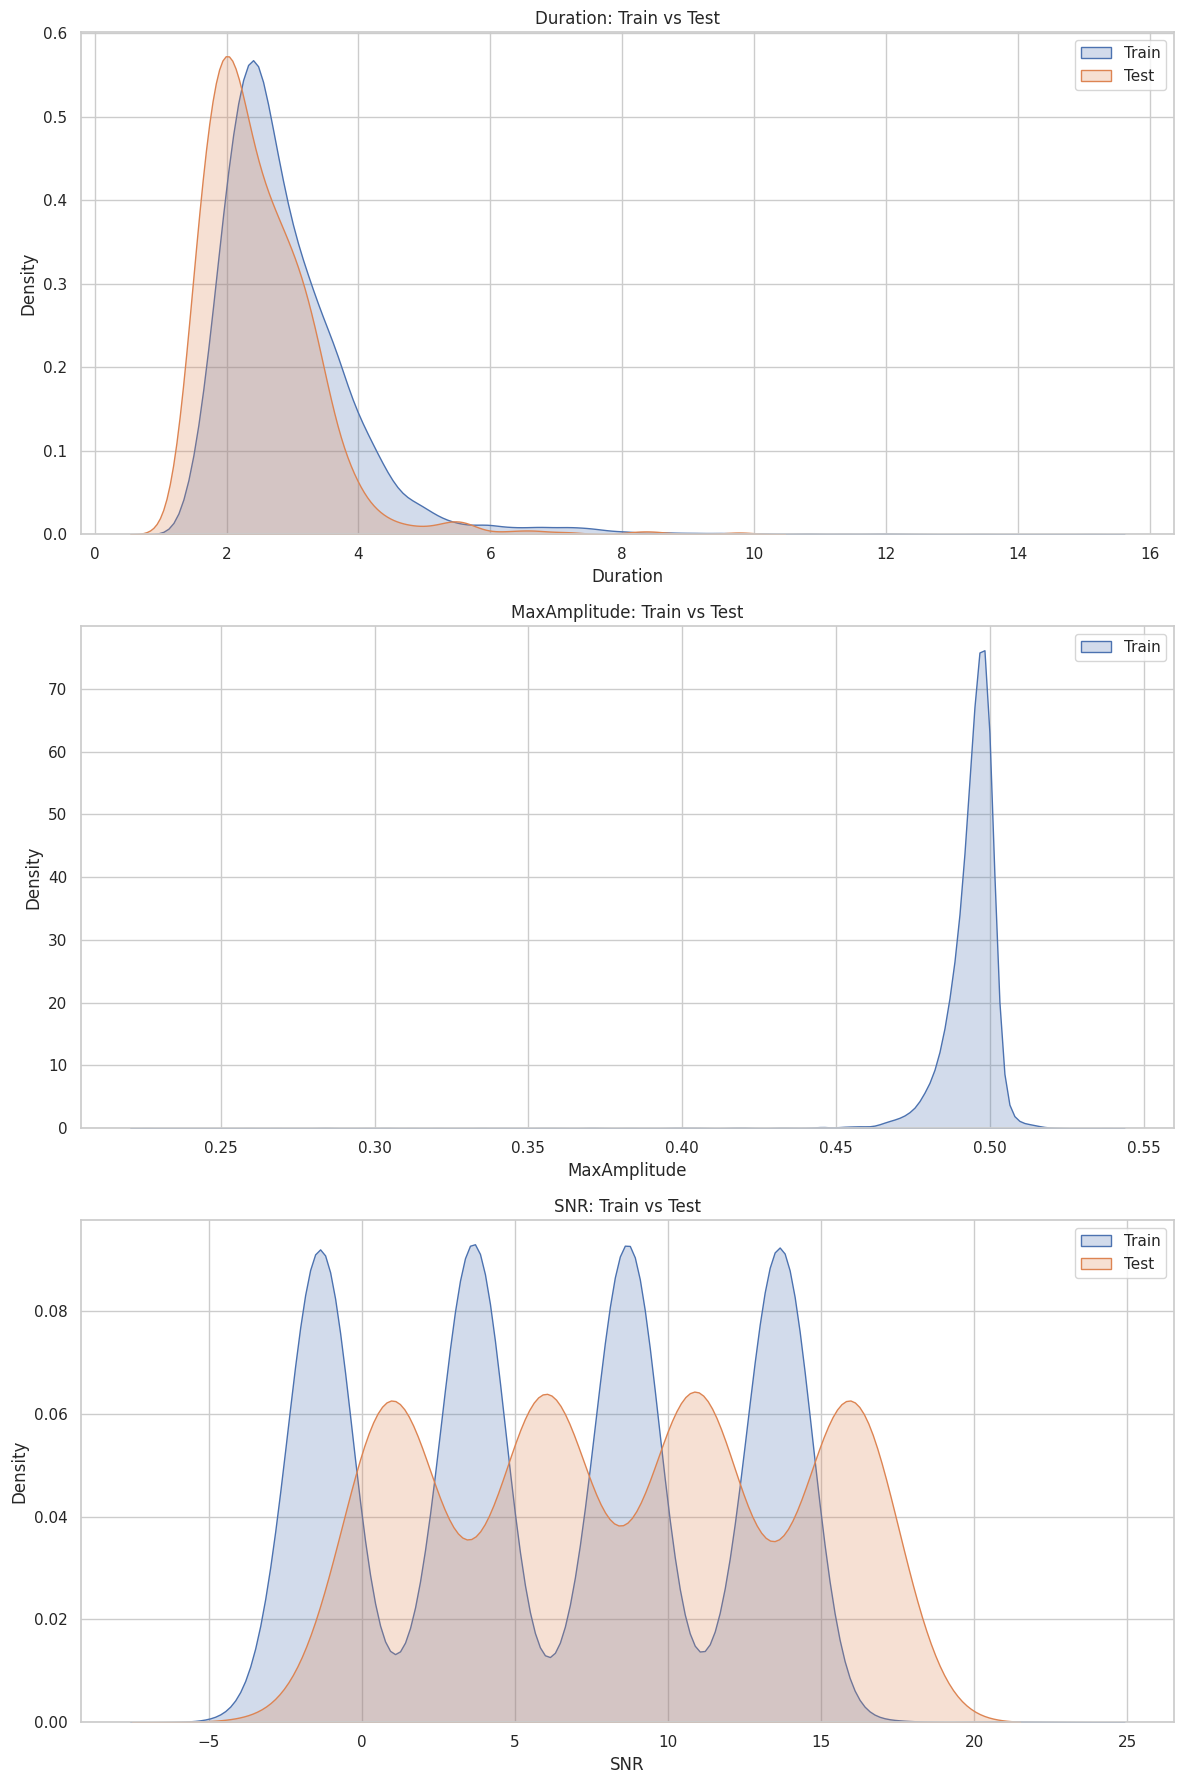

In [7]:

# Train vs Test Distribution Comparisons
fig, axs = plt.subplots(3, 1, figsize=(12, 18))

sns.kdeplot(data=df[df['Set'] == 'train']['Duration'], label='Train', fill=True, ax=axs[0])
sns.kdeplot(data=df[df['Set'] == 'test']['Duration'], label='Test', fill=True, ax=axs[0])
axs[0].set_title("Duration: Train vs Test")
axs[0].legend()

sns.kdeplot(data=df[df['Set'] == 'train']['MaxAmplitude'], label='Train', fill=True, ax=axs[1])
sns.kdeplot(data=df[df['Set'] == 'test']['MaxAmplitude'], label='Test', fill=True, ax=axs[1])
axs[1].set_title("MaxAmplitude: Train vs Test")
axs[1].legend()

sns.kdeplot(data=df[df['Set'] == 'train']['SNR'], label='Train', fill=True, ax=axs[2])
sns.kdeplot(data=df[df['Set'] == 'test']['SNR'], label='Test', fill=True, ax=axs[2])
axs[2].set_title("SNR: Train vs Test")
axs[2].legend()

plt.tight_layout()
plt.show()
